# XGBoost Sybil Detector — LayerZero

Reproduces the tuned XGBoost model from:
> *Sybil Detection on Public Blockchains via XGBoost and Gas Provision Network Analysis*

**Tuned configuration** (via grid search over 15 configs):
- `learning_rate=0.1`, `max_depth=10`, `subsample=0.7`, `colsample_bytree=0.8`
- 3-seed ensemble (seeds 42, 123, 456)
- 5,000 round ceiling with `early_stopping_rounds=50`

**Expected results**: F1 ≈ 0.735, AUROC ≈ 0.974

## 1. Setup

In [23]:
# Install required packages (run once)
# !pip install xgboost lightgbm scikit-learn pandas numpy matplotlib

In [2]:
import os, time, warnings, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_recall_curve, roc_curve, auc,
    f1_score, precision_score, recall_score,
    confusion_matrix, classification_report,
    brier_score_loss, average_precision_score
)
from sklearn.utils import resample

warnings.filterwarnings('ignore')
SEED = 42

In [3]:
# ── Set this to the folder containing all data files ──────────
DATA_DIR = './data'   # <-- adjust if needed

# File paths
L0_FILES = [os.path.join(DATA_DIR, f'20241104_layer0_sybil_features', f'l0_features_{s}.csv')
            for s in ['0_100000','100000_200000','200000_300000',
                      '300000_400000','400000_500000']]
GAS_PROV_FILE  = os.path.join(DATA_DIR, f'20241114_gas_provision', f'20241114_1633_layer0_provision_network_000000000000.csv')
LABELED_FILE   = os.path.join(DATA_DIR, f'20241214_labeled_addresses',f'20241214_labeled_addresses.csv')
TREE_FEAT_FILE = os.path.join(DATA_DIR, f'20241117_tree_features', f'20241117_graph_and_tree_features.csv')
CEX_FILES      = [os.path.join(DATA_DIR, f'20250208_cex_dex_indegree', f'cex_dex_features_in_{s}.csv')
                  for s in [0, 100000, 200000, 300000, 400000]]
SYBIL_FILE     = os.path.join(DATA_DIR, f'20240915_final_sybil_list', f'fcfs_list.csv')

# 63 selected features
FEATS = [
    'min_tx_value_out','gini_coefficient','cex_in_count',
    'leaf_gas_distribution_entropy','star_like_ratio','provider_is_star_like_attack',
    'leaf_gas_distribution_skewness','interactors_in_chain','provider_is_labeled',
    'provider_is_interactor','l0_to_eth_avg_native_drop_usd','l0_to_eth_max_native_drop_usd',
    'balance_factor','l0_tx_time_span','latest_l0_tx_time','time_span_in',
    'provider_total_gas_provision_amount','l0_avg_stargate_swap','avg_depth','breadth_factor',
    'indegree_per_block_in','gas_distribution_skewness','tree_size','l0_min_stargate_swap',
    'provider_max_gas_provision_amount','total_gas','num_transactions_in','branching_factor',
    'l0_to_eth_tx_time_span','n_l0_to_eth_source_contracts','n_l0_to_eth_projects',
    'provider_is_null','max_depth','leaf_provision_proportion',
    'n_l0_to_eth_project_per_source_chain','n_l0_to_eth_txs','earliest_l0_tx_time',
    'n_l0_projects','n_l0_to_eth_dest_contracts','provider_fan_out',
    'l0_to_eth_min_stargate_swap','n_l0_source_chains','longest_chain_ratio',
    'n_eth_interactions','provider_avg_gas_provision_amount','gas_distribution_entropy',
    'sparsity','max_tx_value_out','n_l0_source_contracts','gas_provision_block_number',
    'min_tx_value_in','tx_value_per_block_out','chain_length',
    'provider_min_gas_provision_amount','n_l0_to_eth_source_chains','depth',
    'l0_to_eth_max_stargate_swap','breadth_to_depth_ratio','leaf_to_internal_ratio',
    'earliest_tx_block_in','n_l0_project_per_source_chain','l0_to_eth_avg_stargate_swap',
    'is_provider'
]
print(f'DATA_DIR : {DATA_DIR}')
print(f'Features : {len(FEATS)}')

DATA_DIR : ./data
Features : 63


## 2. Data Loading

Seven steps: L0 base features → gas provision mapping → labeled anchor streaming → tree topology → CEX/DEX counts → Sybil labels → chain traversal.

In [26]:
# ── Step 1: Load L0 base features ─────────────────────────────
t0 = time.time()
chunks = []
for path in L0_FILES:
    c = pd.read_csv(path, na_values=['null', 'NULL'])
    c.columns = c.columns.str.lower()
    chunks.append(c)
df = pd.concat(chunks, ignore_index=True); del chunks; gc.collect()

df = df[df['addr'] != '0x0000000000000000000000000000000000000000']
df.drop(columns=['in_degree', 'out_degree', 'rank'], inplace=True, errors='ignore')
keep = ~df.drop(columns='addr').isnull().all(axis=1)
df = df[keep].drop_duplicates(subset='addr', keep='first').reset_index(drop=True)
print(f'[1] L0 features: {len(df):,} addresses, {len(df.columns)} cols  ({time.time()-t0:.1f}s)')

# ── Step 2: Gas provision mapping ─────────────────────────────
t0 = time.time()
gp = pd.read_csv(GAS_PROV_FILE, usecols=['activated_address', 'gas_provider'],
                 na_values=['', 'null'])
gp.columns = gp.columns.str.lower()
vm = gp['gas_provider'].notna()
tfm = dict(zip(gp.loc[vm, 'activated_address'], gp.loc[vm, 'gas_provider']))
pset = set(tfm.values())
del gp; gc.collect()
print(f'[2] Gas provision: {len(tfm):,} mappings  ({time.time()-t0:.1f}s)')

# ── Step 3: Labeled anchors (memory-efficient streaming) ───────
# Only checks gas provider addresses against the 9M labeled set,
# avoiding loading the full 9M into memory simultaneously.
t0 = time.time()
unique_providers = frozenset(pset)
labeled_anchors = set()
with open(LABELED_FILE) as f:
    for line in f:
        a = line.strip()
        if a and a in unique_providers:
            labeled_anchors.add(a)
labeled_anchors.add('0x9241f27daffd0bb1df4f2a022584dd6c77843e64')

iset = set(df['addr'])
df['_gp'] = df['addr'].map(tfm)
df['provider_is_labeled']    = df['_gp'].isin(labeled_anchors)
df['provider_is_interactor'] = df['_gp'].apply(lambda g: (g in iset) if pd.notna(g) else False)
df['provider_is_null']       = df['_gp'].isna()
df.drop(columns='_gp', inplace=True)
print(f'[3] Labeled anchors: {len(labeled_anchors):,}  ({time.time()-t0:.1f}s)')

# ── Step 4: Tree / topology features ──────────────────────────
t0 = time.time()
tree = pd.read_csv(TREE_FEAT_FILE, na_values=['', 'null'])
tree.columns = tree.columns.str.lower()
tree.drop(columns='provider_is_labeled', inplace=True)   # recomputed above
df = df.merge(tree, on='addr', how='left').fillna(0)
del tree; gc.collect()
print(f'[4] Tree features merged: {len(df):,} rows, {len(df.columns)} cols  ({time.time()-t0:.1f}s)')

# ── Step 5: CEX / DEX in-degree ───────────────────────────────
t0 = time.time()
cex = pd.concat([pd.read_csv(p) for p in CEX_FILES], ignore_index=True)
cex.columns = cex.columns.str.lower()
cex = cex.drop_duplicates(subset='to_address', keep='first')
df  = df.merge(cex, left_on='addr', right_on='to_address', how='left')
df.drop(columns='to_address', inplace=True, errors='ignore')
df.columns = df.columns.str.lower()
df = df.fillna(0)
del cex; gc.collect()
print(f'[5] CEX/DEX merged: {len(df):,} rows, {len(df.columns)} cols  ({time.time()-t0:.1f}s)')

# ── Step 6: Sybil labels + is_provider ────────────────────────
t0 = time.time()
sybil_df = pd.read_csv(SYBIL_FILE)
sybil_df.columns = sybil_df.columns.str.lower().str.strip()
sybil_set = set(sybil_df['address'].str.lower())
df['sybil']       = df['addr'].isin(sybil_set).astype(int)
df['is_provider'] = df['addr'].isin(pset).astype(int)
print(f'[6] Labels: Sybil={df.sybil.sum():,} ({df.sybil.mean()*100:.2f}%)  ({time.time()-t0:.1f}s)')

# ── Step 7: Chain traversal ────────────────────────────────────
t0 = time.time()
clen, icnt = [], []
for addr in df['addr']:
    length, interactors, cur, visited = 0, 0, addr, set()
    while True:
        if cur in visited: break
        visited.add(cur)
        if cur in iset: interactors += 1
        if cur not in tfm: break
        prv = tfm[cur]
        if prv == cur: break
        length += 1
        if prv in labeled_anchors: break
        cur = prv
    clen.append(length); icnt.append(interactors)
df['chain_length']        = clen
df['interactors_in_chain'] = icnt
print(f'[7] Chain features: mean={np.mean(clen):.2f}, max={max(clen)}  ({time.time()-t0:.1f}s)')

# Feature check
missing = [f for f in FEATS if f not in df.columns]
assert not missing, f'Missing features: {missing}'
print(f'All {len(FEATS)} features present ✓')

[1] L0 features: 434,786 addresses, 55 cols  (4.7s)
[2] Gas provision: 604,661 mappings  (2.6s)
[3] Labeled anchors: 3,698  (8.4s)
[4] Tree features merged: 434,787 rows, 89 cols  (3.7s)
[5] CEX/DEX merged: 434,787 rows, 91 cols  (1.9s)
[6] Labels: Sybil=18,211 (4.19%)  (1.2s)
[7] Chain features: mean=1.88, max=504  (2.2s)
All 63 features present ✓


## 3. Train / Validation / Test Split

In [27]:
# ── Train / Val / Test split + minority upsampling ────────────
X = df[FEATS].astype(np.float32)
y = df['sybil'].astype(int)

# 70/21/30 split — mirrors the paper's partitioning
X_tr0, X_test, y_tr0, y_test = train_test_split(X, y, test_size=0.30,
                                                  random_state=SEED, stratify=y)
X_tr1, X_val,  y_tr1, y_val  = train_test_split(X_tr0, y_tr0, test_size=0.30,
                                                  random_state=SEED, stratify=y_tr0)

# Upsample Sybil class to 1:1 in training set only
tr = pd.concat([X_tr1, y_tr1.rename('sybil')], axis=1)
maj = tr[tr['sybil'] == 0]
mn  = tr[tr['sybil'] == 1]
mn_up = resample(mn, replace=True, n_samples=len(maj), random_state=SEED)
bal = pd.concat([maj, mn_up]).sample(frac=1, random_state=SEED)
X_train = bal.drop(columns='sybil').astype(np.float32)
y_train = bal['sybil']

print(f'Train (balanced) : {len(X_train):,}  ({y_train.mean()*100:.1f}% Sybil)')
print(f'Validation       : {len(X_val):,}   ({y_val.mean()*100:.2f}% Sybil)')
print(f'Test             : {len(X_test):,}  ({y_test.mean()*100:.2f}% Sybil)')

Train (balanced) : 408,242  (50.0% Sybil)
Validation       : 91,305   (4.19% Sybil)
Test             : 130,437  (4.19% Sybil)


## 4. Evaluation Helpers

In [28]:
# ── Evaluation helpers ────────────────────────────────────────
def optimal_threshold(y_true, probs):
    """Find threshold that maximises F1 on the given set."""
    prec, rec, thresholds = precision_recall_curve(y_true, probs)
    f1 = np.where((prec + rec) > 0, 2 * prec * rec / (prec + rec), 0)
    return float(thresholds[np.argmax(f1[:-1])])

def evaluate(name, val_probs, test_probs, y_val, y_test, threshold=None):
    """Evaluate model at optimal val threshold, report test metrics."""
    thr = threshold if threshold is not None else optimal_threshold(y_val, val_probs)
    y_pred = (test_probs >= thr).astype(int)
    fpr, tpr, _ = roc_curve(y_test, test_probs)
    prc, rec, _ = precision_recall_curve(y_test, test_probs)
    results = dict(
        name      = name,
        threshold = thr,
        precision = precision_score(y_test, y_pred, zero_division=0),
        recall    = recall_score(y_test, y_pred,    zero_division=0),
        f1        = f1_score(y_test, y_pred,         zero_division=0),
        auroc     = auc(fpr, tpr),
        ap        = average_precision_score(y_test, test_probs),
        brier     = brier_score_loss(y_test, test_probs),
        fpr=fpr, tpr=tpr, prc=prc, rec_c=rec,
    )
    print(f'  Threshold : {thr:.4f}')
    print(f'  Precision : {results["precision"]:.4f}')
    print(f'  Recall    : {results["recall"]:.4f}')
    print(f'  F1        : {results["f1"]:.4f}')
    print(f'  AUROC     : {results["auroc"]:.4f}')
    print(f'  Avg Prec  : {results["ap"]:.4f}')
    print(f'  Brier     : {results["brier"]:.4f}')
    print(classification_report(y_test, y_pred, digits=4))
    return results

def plot_curves(results_list):
    """Plot ROC and PR curves for one or more models."""
    colors = ['#1565C0','#2E7D32','#B71C1C','#6A1B9A','#E65100']
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for r, c in zip(results_list, colors):
        axes[0].plot(r['fpr'], r['tpr'], color=c, lw=2,
                     label=f"{r['name']}  AUC={r['auroc']:.4f}")
        axes[1].plot(r['rec_c'], r['prc'], color=c, lw=2,
                     label=f"{r['name']}  AP={r['ap']:.4f}")
    axes[0].plot([0,1],[0,1],'k--',alpha=0.3,lw=1)
    axes[0].set(xlabel='FPR', ylabel='TPR', title='ROC Curve')
    axes[0].legend(fontsize=9); axes[0].grid(alpha=0.2)
    axes[1].set(xlabel='Recall', ylabel='Precision', title='Precision-Recall Curve')
    axes[1].legend(fontsize=9, loc='upper right'); axes[1].grid(alpha=0.2)
    plt.tight_layout(); plt.show()

## 5. Train XGBoost (3-Seed Ensemble)

In [29]:
from xgboost import XGBClassifier

# ── Tuned parameters (found via grid search) ──────────────────
XGB_PARAMS = dict(
    objective         = 'binary:logistic',
    n_estimators      = 5000,          # hard ceiling; early stopping controls actual rounds
    learning_rate     = 0.1,           # vs default 0.3; slower = better generalisation
    max_depth         = 10,            # vs default 6; captures higher-order interactions
    subsample         = 0.7,           # row subsampling per tree
    colsample_bytree  = 0.8,           # column subsampling per tree
    eval_metric       = 'logloss',
    early_stopping_rounds = 50,
    verbosity         = 0,
)

# ── 3-seed ensemble (averages variance across random initialisations) ──
SEEDS = [42, 123, 456]
val_probs_list  = []
test_probs_list = []

for seed in SEEDS:
    print(f'Training seed={seed}...', flush=True)
    t0 = time.time()
    model = XGBClassifier(**XGB_PARAMS, random_state=seed, tree_method='hist')
    model.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              verbose=False)
    val_probs_list.append(model.predict_proba(X_val)[:,1])
    test_probs_list.append(model.predict_proba(X_test)[:,1])
    print(f'  best_iteration={model.best_iteration}  time={time.time()-t0:.1f}s')

xgb_val_probs  = np.mean(val_probs_list,  axis=0)
xgb_test_probs = np.mean(test_probs_list, axis=0)
print('\nEnsemble probabilities computed.')

Training seed=42...
  best_iteration=493  time=42.7s
Training seed=123...
  best_iteration=449  time=50.5s
Training seed=456...
  best_iteration=480  time=75.5s

Ensemble probabilities computed.


## 6. Evaluate on Test Set

=== XGBoost 3-Seed Ensemble — Test Set Results ===
  Threshold : 0.5332
  Precision : 0.7235
  Recall    : 0.7481
  F1        : 0.7356
  AUROC     : 0.9739
  Avg Prec  : 0.7949
  Brier     : 0.0181
              precision    recall  f1-score   support

           0     0.9890    0.9875    0.9882    124974
           1     0.7235    0.7481    0.7356      5463

    accuracy                         0.9775    130437
   macro avg     0.8562    0.8678    0.8619    130437
weighted avg     0.9779    0.9775    0.9777    130437



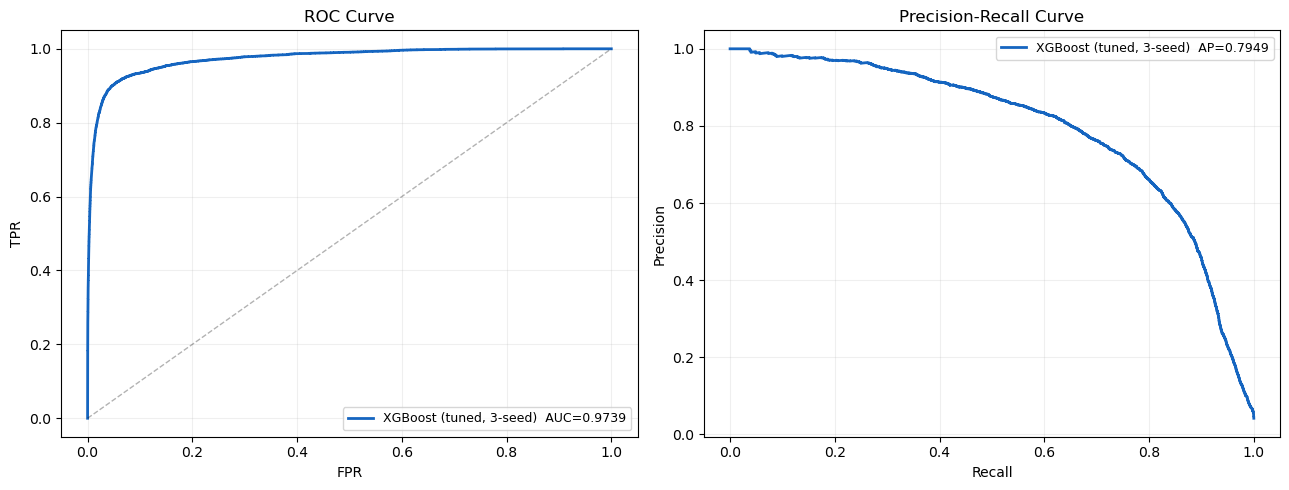

In [30]:
print('=== XGBoost 3-Seed Ensemble — Test Set Results ===')
xgb_results = evaluate('XGBoost (tuned, 3-seed)',
                        xgb_val_probs, xgb_test_probs, y_val, y_test)
plot_curves([xgb_results])

## 7. Feature Importances

Top 20 features (normalized Gini gain):
                       Feature  NormGain
  n_l0_to_eth_source_contracts  0.090433
                balance_factor  0.058368
            n_l0_source_chains  0.051320
           num_transactions_in  0.038528
               l0_tx_time_span  0.034656
          interactors_in_chain  0.034050
              provider_is_null  0.031951
        l0_to_eth_tx_time_span  0.030547
        provider_is_interactor  0.025545
               n_l0_to_eth_txs  0.025223
      gas_distribution_entropy  0.024959
              branching_factor  0.022280
   l0_to_eth_max_stargate_swap  0.019207
          n_l0_to_eth_projects  0.018223
leaf_gas_distribution_skewness  0.018184
     leaf_provision_proportion  0.017983
            n_eth_interactions  0.017587
                     max_depth  0.017253
          earliest_tx_block_in  0.016748
        breadth_to_depth_ratio  0.016601


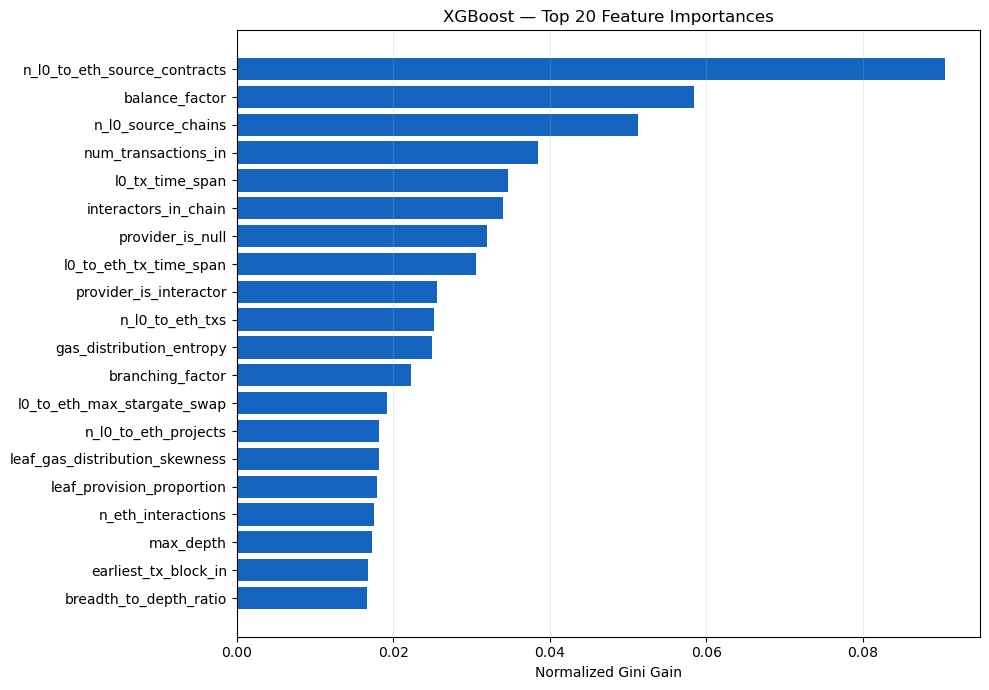

In [31]:
# ── Feature importance (last trained model) ───────────────────
name_map = {f'f{i}': name for i, name in enumerate(FEATS)}
raw_imp  = model.get_booster().get_score(importance_type='gain')
total    = sum(raw_imp.values())
imp_df   = pd.DataFrame(
    [(name_map.get(k, k), v / total) for k, v in sorted(raw_imp.items(), key=lambda x: -x[1])],
    columns=['Feature', 'NormGain']
)
print('Top 20 features (normalized Gini gain):')
print(imp_df.head(20).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 7))
top20 = imp_df.head(20)
ax.barh(top20['Feature'][::-1], top20['NormGain'][::-1], color='#1565C0')
ax.set(xlabel='Normalized Gini Gain',
       title='XGBoost — Top 20 Feature Importances')
ax.grid(axis='x', alpha=0.25)
plt.tight_layout(); plt.show()

## 8. Operating Point Table

In [32]:
# ── Operating point table ─────────────────────────────────────
n_sybil = int(y_test.sum()); n_clean = len(y_test) - n_sybil
print(f'\nTest set: {len(y_test):,} total | {n_sybil:,} Sybil | {n_clean:,} Non-Sybil\n')
print(f'  {"Threshold":<10} {"Precision":<11} {"Recall":<10} {"F1":<9} {"Flagged":<11} {"False+"}')
print('-'*65)
for t in [0.95, 0.90, 0.85, 0.80, 0.75, 0.70, round(xgb_results["threshold"], 2), 0.50]:
    y_pred = (xgb_test_probs >= t).astype(int)
    if y_pred.sum() == 0: continue
    tp_ = int(((y_pred==1)&(y_test==1)).sum()); fp_ = int(((y_pred==1)&(y_test==0)).sum())
    p = tp_/(tp_+fp_); r = tp_/n_sybil; f1v = 2*p*r/(p+r) if p+r>0 else 0
    mark = ' ←opt' if abs(t - xgb_results['threshold']) < 0.03 else ''
    print(f'  {t:<10.2f} {p:<11.4f} {r:<10.4f} {f1v:<9.4f} {y_pred.sum():<11,} {fp_:,}{mark}')


Test set: 130,437 total | 5,463 Sybil | 124,974 Non-Sybil

  Threshold  Precision   Recall     F1        Flagged     False+
-----------------------------------------------------------------
  0.95       0.8706      0.5122     0.6449    3,214       416
  0.90       0.8385      0.5854     0.6894    3,814       616
  0.85       0.8231      0.6227     0.7090    4,133       731
  0.80       0.8024      0.6482     0.7171    4,413       872
  0.75       0.7861      0.6707     0.7238    4,661       997
  0.70       0.7691      0.6884     0.7266    4,890       1,129
  0.53       0.7224      0.7494     0.7357    5,667       1,573 ←opt
  0.50       0.7111      0.7562     0.7330    5,809       1,678
